# SuperCDMS LED — Machine Learning Pipeline

Three ML models built on the same data as `LED data.ipynb`:

| Model | Task | Algorithm |
|-------|------|-----------|
| 1 | Event quality classifier (good / no-pulse / glitch) | Random Forest |
| 2 | Glitch detector — feature-based + waveform-based | RF + MLP |
| 3 | Time-constant regressor (predict τ from waveform) | 1D-CNN (PyTorch) / MLP fallback |

Labels come from `glitch_event_dict.npy` and `good_event_dict` built in `LED data.ipynb`.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
from scipy.optimize import curve_fit
import warnings

# sklearn
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, r2_score
)
from sklearn.inspection import permutation_importance

# PyTorch (optional — falls back to MLP if not available)
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_OK = True
    print(f'PyTorch {torch.__version__} available')
except ImportError:
    TORCH_OK = False
    print('PyTorch not found — Model 3 will use sklearn MLP')

import rawio
import cdms
print('CDMS version:', cdms.get_global_version())
%matplotlib inline

PyTorch not found — Model 3 will use sklearn MLP
CDMS version: V07-02-00


## 0. Load Raw Events
Exact same path / parameters as `LED data.ipynb`.

In [29]:
# ── paths (copy from LED data.ipynb) ─────────────────────────────────────────
DATA_DIR   = "/projects/standard/yanliusp/shared/data/CDMS/CUTE/R37/Raw/23231213_192731"
FILEPATH   = f"{DATA_DIR}/23231213_192731_F0003.mid.gz"
LABEL_DIR  = "/users/9/li004628/urop/LED"   # where .npy files are saved

# channels (T3Z3 has no PAS1)
chanNames = ["PBS1","PCS1","PDS1","PES1","PFS1",
             "PAS2","PBS2","PCS2","PDS2","PES2","PFS2"]

# read events
myreader = rawio.RawDataReader(FILEPATH)
nb       = myreader.get_nb_events()
print(nb)

events = myreader.read_events(
    output_format  = 2,
    skip_empty     = True,
    nb_events      = nb["NbEventsNotEmpty"],
    trigger_types  = [1],
    detector_nums  = [1, 2, 3],
    channel_names  = chanNames
)
print(f'Loaded {len(events)} events')

INFO: Found 1 midas raw data files
{'NbEventsAll': 1103, 'NbEventsNotEmpty': 775, 'NbEventsEORR': 0, 'NbEventsBORR': 0, 'NbEventsEORTS': 0, 'NbEventsBORTS': 0}
Loaded 629 events


In [30]:
import os

# load labels saved by LED data.ipynb
glitch_event_dict = np.load(
    os.path.join(LABEL_DIR, "glitch_event_dict.npy"), allow_pickle=True
).item()
template_dict = np.load(
    os.path.join(LABEL_DIR, "template_dict.npy"), allow_pickle=True
).item()

print('glitch_event_dict loaded:', {Z: {ch: len(v) for ch, v in d.items()}
      for Z, d in glitch_event_dict.items()})

glitch_event_dict loaded: {'Z1': {'PFS1': 0, 'PCS1': 1, 'PDS1': 0, 'PBS1': 2, 'PES1': 0, 'PFS2': 0, 'PCS2': 0, 'PBS2': 0, 'PES2': 0, 'PDS2': 0, 'PAS2': 0}, 'Z2': {'PFS1': 1, 'PCS1': 1, 'PDS1': 1, 'PBS1': 1, 'PES1': 0, 'PFS2': 2, 'PCS2': 0, 'PBS2': 1, 'PES2': 1, 'PDS2': 1, 'PAS2': 1}, 'Z3': {'PFS1': 0, 'PCS1': 0, 'PDS1': 0, 'PBS1': 0, 'PES1': 0, 'PFS2': 0, 'PCS2': 0, 'PBS2': 0, 'PES2': 0, 'PDS2': 0, 'PAS2': 0}}


## 1. Feature Extraction
For each (Z, channel, event_index) we compute a feature vector:

| Feature | Description |
|---------|-------------|
| `amplitude` | max − min of raw ADC |
| `baseline` | mean of first 5000 samples |
| `peak` | max after baseline subtraction |
| `snr` | peak / std(pre-trigger noise) |
| `pre_min` | min of normalised signal in window [24.9, 25.25] ms |
| `rise_time` | samples from 10 % → 90 % of peak |
| `half_decay` | samples from peak → 50 % of peak |
| `tail_mean` | mean of last 2000 samples (residual baseline) |

In [31]:
FS = 625000
N  = 32768
x0_ms = np.arange(N) / FS * 1000   # time axis in ms

def butter_lp(data, cutoff_khz=10, fs=625000, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff_khz * 1000 / nyq, btype='low', analog=False)
    return lfilter(b, a, data)

def extract_features(y_raw):
    """Returns feature dict or None if event has no pulse."""
    y = y_raw.astype(np.float64)
    amplitude = float(np.max(y) - np.min(y))
    baseline  = float(np.mean(y[:5000]))
    y_sub     = y - baseline
    peak      = float(np.max(y_sub))

    if peak <= 0:
        return None

    y_norm = y_sub / peak
    snr    = float(peak / (np.std(y_sub[:5000]) + 1e-9))

    # rise time (10 % → 90 %)
    peak_idx = int(np.argmax(y_norm))
    pre      = y_norm[:peak_idx]
    r10 = next((i for i, v in enumerate(pre) if v >= 0.10), peak_idx)
    r90 = next((i for i, v in enumerate(pre) if v >= 0.90), peak_idx)
    rise_time = float(r90 - r10)

    # half-decay
    post      = y_norm[peak_idx:]
    hd        = next((i for i, v in enumerate(post) if v <= 0.5), len(post))
    half_decay = float(hd)

    # pre-pulse min (glitch indicator) — need aligned x
    # find rise edge (same logic as LED data.ipynb)
    gap, x_target, found, rise_ms = 0.05, 0.0, False, None
    while x_target < 29.0:
        idx_a = int(np.argmin(np.abs(x0_ms - x_target)))
        idx_b = int(np.argmin(np.abs(x0_ms - (x_target + gap))))
        if y_norm[idx_b] - y_norm[idx_a] > 0.2:
            rise_ms, found = x_target, True
            break
        x_target += gap

    if found:
        x_aligned = x0_ms - (rise_ms - 25.3)
        mask      = (x_aligned >= 24.9) & (x_aligned <= 25.25)
        pre_min   = float(np.min(y_norm[mask])) if np.any(mask) else 0.0
    else:
        pre_min = 0.0

    tail_mean = float(np.mean(y_norm[-2000:]))

    return dict(
        amplitude  = amplitude,
        baseline   = baseline,
        peak       = peak,
        snr        = snr,
        pre_min    = pre_min,
        rise_time  = rise_time,
        half_decay = half_decay,
        tail_mean  = tail_mean,
        has_rise   = float(found)
    )

FEAT_NAMES = ['amplitude','baseline','peak','snr',
              'pre_min','rise_time','half_decay','tail_mean','has_rise']
print('Feature extractor ready. Features:', FEAT_NAMES)

Feature extractor ready. Features: ['amplitude', 'baseline', 'peak', 'snr', 'pre_min', 'rise_time', 'half_decay', 'tail_mean', 'has_rise']


In [32]:
# ── Build labelled feature matrix ─────────────────────────────────────────────
# label: 0 = no_pulse, 1 = good, 2 = glitch
LABEL_MAP = {'no_pulse': 0, 'good': 1, 'glitch': 2}

rows, labels, meta = [], [], []

Z_list = ['Z1', 'Z2', 'Z3']

for Z in Z_list:
    for ch in chanNames:
        glitch_idx = set(glitch_event_dict[Z].get(ch, []))
        for i in range(len(events)):
            if Z not in events[i] or ch not in events[i][Z]:
                continue
            y_raw = events[i][Z][ch]
            feat  = extract_features(y_raw)

            # label
            if feat is None or feat['amplitude'] <= 2000:
                label = 'no_pulse'
            elif i in glitch_idx:
                label = 'glitch'
            elif feat['has_rise'] and feat['amplitude'] > 2000:
                label = 'good'
            else:
                label = 'no_pulse'

            if feat is not None:
                rows.append([feat[f] for f in FEAT_NAMES])
                labels.append(LABEL_MAP[label])
                meta.append((Z, ch, i))

X      = np.array(rows, dtype=np.float32)
y_cls  = np.array(labels, dtype=np.int32)
label_names = ['no_pulse', 'good', 'glitch']

print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features')
for k, v in LABEL_MAP.items():
    print(f'  {k:10s}: {np.sum(y_cls == v)}')

Dataset: 20757 samples, 9 features
  no_pulse  : 19849
  good      : 895
  glitch    : 13


---
## Model 1 — Event Quality Classifier
**Task**: classify each (Z, channel, event) as `good` / `no_pulse` / `glitch`  
**Algorithm**: Random Forest (interpretable, handles small + imbalanced data)

In [33]:
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_cls)
class_weight_dict = {0: cw[0], 1: cw[1], 2: cw[2]}

rf = RandomForestClassifier(
    n_estimators   = 300,
    max_depth      = None,
    class_weight   = class_weight_dict,
    random_state   = 42,
    n_jobs         = -1
)

# 5-fold stratified CV
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X, y_cls, cv=cv, scoring='f1_macro')
print(f'CV F1-macro: {scores.mean():.3f} ± {scores.std():.3f}')

# train on full data for inspection
rf.fit(X, y_cls)
y_pred = rf.predict(X)
print('\nClassification report (train):')
print(classification_report(y_cls, y_pred, target_names=label_names))

CV F1-macro: 0.910 ± 0.130

Classification report (train):
              precision    recall  f1-score   support

    no_pulse       1.00      1.00      1.00     19849
        good       1.00      1.00      1.00       895
      glitch       1.00      1.00      1.00        13

    accuracy                           1.00     20757
   macro avg       1.00      1.00      1.00     20757
weighted avg       1.00      1.00      1.00     20757



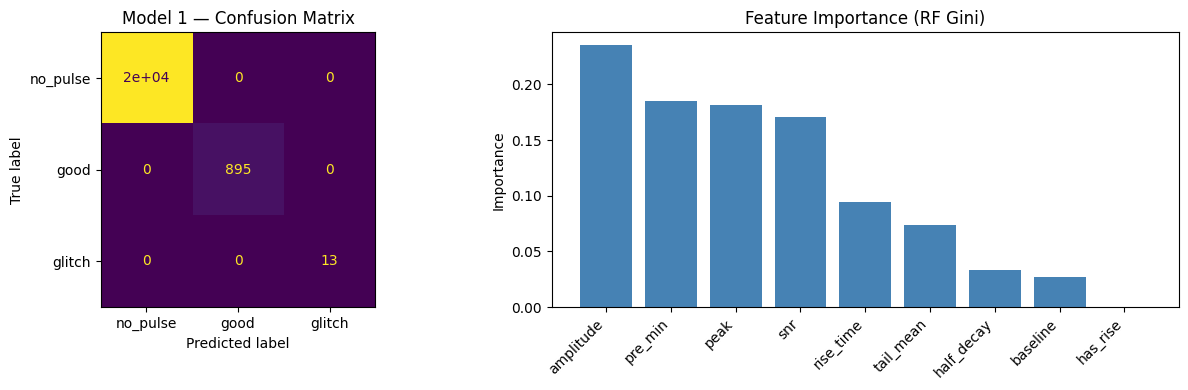

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# confusion matrix
cm = confusion_matrix(y_cls, y_pred)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Model 1 — Confusion Matrix')

# feature importance
imp = rf.feature_importances_
order = np.argsort(imp)[::-1]
axes[1].bar(range(len(FEAT_NAMES)), imp[order], color='steelblue')
axes[1].set_xticks(range(len(FEAT_NAMES)))
axes[1].set_xticklabels([FEAT_NAMES[o] for o in order], rotation=45, ha='right')
axes[1].set_title('Feature Importance (RF Gini)')
axes[1].set_ylabel('Importance')
plt.tight_layout()
plt.show()

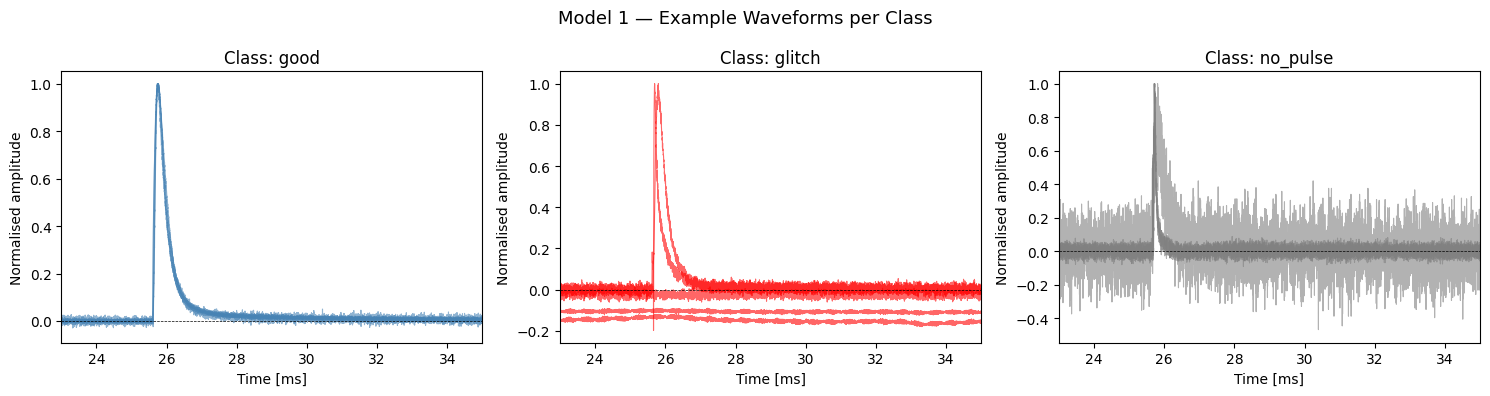

In [35]:

# ── Model 1 result: example waveforms for each predicted class ────────────────
t_ms_full = np.arange(N) / FS * 1000
label_colors = {0: 'gray', 1: 'steelblue', 2: 'red'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (cls_id, cls_name) in zip(axes, [(1,'good'), (2,'glitch'), (0,'no_pulse')]):
    # find first few events of this predicted class
    idx_cls = np.where(y_cls == cls_id)[0][:5]
    for k in idx_cls:
        Z_k, ch_k, ev_k = meta[k]
        y_raw = events[ev_k][Z_k][ch_k].astype(np.float64)
        baseline = np.mean(y_raw[:5000])
        y_plot = (y_raw - baseline)
        peak = np.max(np.abs(y_plot))
        if peak > 0:
            y_plot = y_plot / peak
        ax.plot(t_ms_full, y_plot, alpha=0.6, lw=0.8,
                color=label_colors[cls_id])
    ax.set_title(f'Class: {cls_name}', fontsize=12)
    ax.set_xlabel('Time [ms]')
    ax.set_ylabel('Normalised amplitude')
    ax.set_xlim(23, 35)
    ax.axhline(0, color='black', lw=0.5, ls='--')
fig.suptitle('Model 1 — Example Waveforms per Class', fontsize=13)
plt.tight_layout()
plt.show()


---
## Model 2 — Glitch Detector
**Task**: binary classification — glitch vs good (on events that have a pulse)  
**Algorithms**: Random Forest + MLP, compare both

In [36]:
# keep only events that have a pulse (good or glitch)
pulse_mask  = y_cls != LABEL_MAP['no_pulse']
X_pulse     = X[pulse_mask]
y_glitch    = (y_cls[pulse_mask] == LABEL_MAP['glitch']).astype(np.int32)  # 1=glitch, 0=good

print(f'Pulse events: {X_pulse.shape[0]}')
print(f'  good  : {np.sum(y_glitch == 0)}')
print(f'  glitch: {np.sum(y_glitch == 1)}')

Pulse events: 908
  good  : 895
  glitch: 13


In [37]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_pulse)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y_glitch, test_size=0.25, random_state=42, stratify=y_glitch
)

# ── Random Forest ─────────────────────────────────────────────────────────────
rf2 = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1
)
rf2.fit(X_tr, y_tr)
rf2_pred = rf2.predict(X_te)

print('=== Random Forest ===')
print(classification_report(y_te, rf2_pred, target_names=['good','glitch']))

# ── MLP ──────────────────────────────────────────────────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42
)
mlp.fit(X_tr, y_tr)
mlp_pred = mlp.predict(X_te)

print('=== MLP (sklearn) ===')
print(classification_report(y_te, mlp_pred, target_names=['good','glitch']))

=== Random Forest ===
              precision    recall  f1-score   support

        good       1.00      1.00      1.00       224
      glitch       0.75      1.00      0.86         3

    accuracy                           1.00       227
   macro avg       0.88      1.00      0.93       227
weighted avg       1.00      1.00      1.00       227

=== MLP (sklearn) ===
              precision    recall  f1-score   support

        good       1.00      1.00      1.00       224
      glitch       0.67      0.67      0.67         3

    accuracy                           0.99       227
   macro avg       0.83      0.83      0.83       227
weighted avg       0.99      0.99      0.99       227



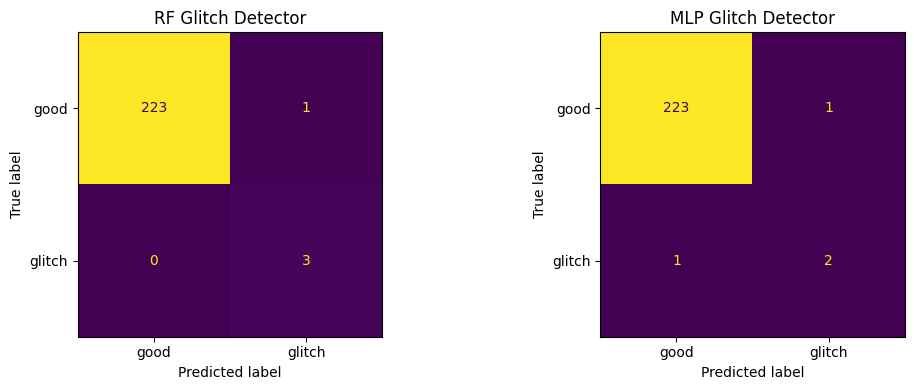

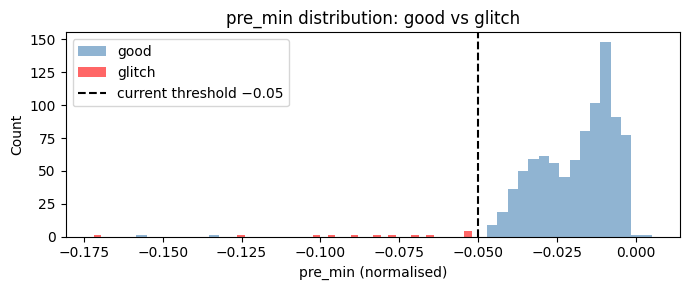

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, title in zip(axes,
                            [rf2_pred, mlp_pred],
                            ['RF Glitch Detector', 'MLP Glitch Detector']):
    cm = confusion_matrix(y_te, pred)
    ConfusionMatrixDisplay(cm, display_labels=['good','glitch']).plot(ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

# pre_min distribution — the most discriminative feature
pre_min_idx = FEAT_NAMES.index('pre_min')
plt.figure(figsize=(7, 3))
plt.hist(X_pulse[y_glitch == 0, pre_min_idx], bins=50, alpha=0.6, label='good', color='steelblue')
plt.hist(X_pulse[y_glitch == 1, pre_min_idx], bins=50, alpha=0.6, label='glitch', color='red')
plt.axvline(-0.05, color='black', ls='--', label='current threshold −0.05')
plt.xlabel('pre_min (normalised)')
plt.ylabel('Count')
plt.title('pre_min distribution: good vs glitch')
plt.legend()
plt.tight_layout()
plt.show()

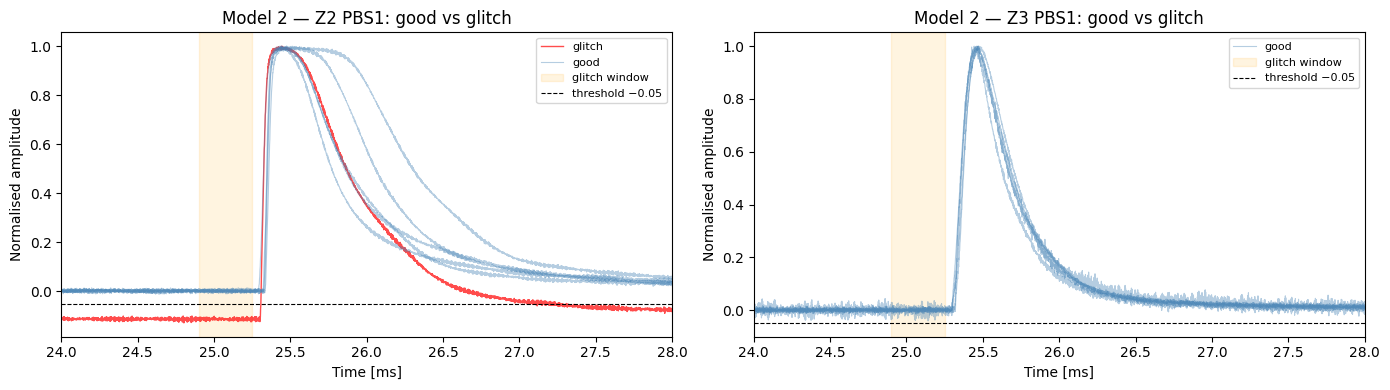

In [39]:

# ── Model 2 result: good vs glitch waveform comparison (aligned) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, Z_show, ch_show in zip(axes, ['Z2', 'Z3'], ['PBS1', 'PBS1']):
    glitch_evs = glitch_event_dict[Z_show].get(ch_show, [])
    if not glitch_evs:
        # fallback: find any channel with glitches
        for ch_try in chanNames:
            if glitch_event_dict[Z_show].get(ch_try):
                ch_show = ch_try
                glitch_evs = glitch_event_dict[Z_show][ch_show]
                break

    # plot a few glitch events
    for ev_i in glitch_evs[:3]:
        y_raw = events[ev_i][Z_show][ch_show].astype(np.float64)
        baseline = np.mean(y_raw[:5000])
        y_n = (y_raw - baseline)
        peak = np.max(y_n) if np.max(y_n) > 0 else 1
        y_n = y_n / peak

        gap, x_target, rise_ms = 0.05, 0.0, None
        while x_target < 29.0:
            ia = int(np.argmin(np.abs(x0_ms - x_target)))
            ib = int(np.argmin(np.abs(x0_ms - (x_target + gap))))
            if y_n[ib] - y_n[ia] > 0.2:
                rise_ms = x_target
                break
            x_target += gap
        if rise_ms is not None:
            x_al = x0_ms - (rise_ms - 25.3)
            ax.plot(x_al, y_n, color='red', alpha=0.7, lw=1,
                    label='glitch' if ev_i == glitch_evs[0] else '')

    # plot a few good events from same channel
    count = 0
    for i in range(len(events)):
        if i in set(glitch_evs):
            continue
        if Z_show not in events[i] or ch_show not in events[i][Z_show]:
            continue
        y_raw = events[i][Z_show][ch_show].astype(np.float64)
        if np.max(y_raw) - np.min(y_raw) <= 2000:
            continue
        baseline = np.mean(y_raw[:5000])
        y_n = (y_raw - baseline)
        peak = np.max(y_n) if np.max(y_n) > 0 else 1
        y_n = y_n / peak

        gap, x_target, rise_ms = 0.05, 0.0, None
        while x_target < 29.0:
            ia = int(np.argmin(np.abs(x0_ms - x_target)))
            ib = int(np.argmin(np.abs(x0_ms - (x_target + gap))))
            if y_n[ib] - y_n[ia] > 0.2:
                rise_ms = x_target
                break
            x_target += gap
        if rise_ms is not None:
            x_al = x0_ms - (rise_ms - 25.3)
            ax.plot(x_al, y_n, color='steelblue', alpha=0.4, lw=0.8,
                    label='good' if count == 0 else '')
            count += 1
            if count >= 5:
                break

    ax.axvspan(24.9, 25.25, alpha=0.12, color='orange', label='glitch window')
    ax.axhline(-0.05, color='black', lw=0.8, ls='--', label='threshold −0.05')
    ax.set_xlim(24.0, 28.0)
    ax.set_xlabel('Time [ms]')
    ax.set_ylabel('Normalised amplitude')
    ax.set_title(f'Model 2 — {Z_show} {ch_show}: good vs glitch')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## Model 3 — Time-Constant Regressor
**Task**: predict decay time constant τ (t2) directly from the aligned waveform  
**Input**: normalised waveform window `[14000:28000]` (22.4 ms — covers rise + decay)  
**Target**: t2 estimated from half-decay time (same `auto_guess` logic as LED data.ipynb)  
**Model**: 1D-CNN (PyTorch) if available, sklearn MLP otherwise

In [ ]:

# ── Model 3 prep: robust t2 + feature-based regression dataset ────────────────
#
# Problem with previous approach:
#   - Using half-decay POINT as target → very noisy, huge outliers
#   - Using raw waveform (14000 features) as input → MLP cannot converge
#
# New approach:
#   - Target:  log-linear fit on decay region 5%–90% → much more robust
#   - Input:   same 9 statistical features as Model 1/2 → no dimensionality issue
#   - Model:   Random Forest Regressor (works well on small data)
#

def align_waveform(y_raw):
    """Align to 25.3 ms rise. Returns y_rolled (32768 samples) or None."""
    y = y_raw.astype(np.float64)
    baseline = np.mean(y[:5000])
    if np.max(y) - np.min(y) <= 2000 or abs(baseline) >= 33100:
        return None
    y_sub = y - baseline
    peak  = np.max(y_sub)
    if peak <= 0:
        return None
    y_norm   = y_sub / peak
    rise_idx = None
    x_t = 0.0
    while x_t < 29.0:
        ia = int(np.argmin(np.abs(x0_ms - x_t)))
        ib = int(np.argmin(np.abs(x0_ms - (x_t + 0.05))))
        if y_norm[ib] - y_norm[ia] > 0.2:
            rise_idx = ia
            break
        x_t += 0.05
    if rise_idx is None:
        return None
    ref_idx = int(np.argmin(np.abs(x0_ms - 25.3)))
    return np.roll(y_norm, ref_idx - rise_idx)

def fit_decay_t2(y_rolled, samplerate=625000):
    """Log-linear fit on 5%–90% of peak. Returns t2 (seconds) or None."""
    peak_idx = int(np.argmax(y_rolled))
    y_peak   = float(y_rolled[peak_idx])
    if y_peak <= 0:
        return None
    post = y_rolled[peak_idx:] / y_peak
    mask = (post >= 0.05) & (post <= 0.90)
    if np.sum(mask) < 10:
        return None
    t_sec = np.where(mask)[0] / samplerate
    log_y = np.log(np.clip(post[mask], 1e-9, None))
    try:
        a, _ = np.polyfit(t_sec, log_y, 1)
        if a >= 0:         # not decaying
            return None
        t2 = float(-1.0 / a)
        return t2 if 5e-5 < t2 < 0.05 else None   # 0.05 ms – 50 ms physical range
    except Exception:
        return None

# ── Build regression dataset ──────────────────────────────────────────────────
X_reg, y_reg, meta_reg = [], [], []
aligned_waves_all = {}     # (Z, ch) → [(ev_idx, y_rolled), ...]  for plotting

for Z in Z_list:
    for ch in chanNames:
        glitch_idx = set(glitch_event_dict[Z].get(ch, []))
        aligned_waves_all[(Z, ch)] = []
        for i in range(len(events)):
            if Z not in events[i] or ch not in events[i][Z]:
                continue
            if i in glitch_idx:
                continue
            y_raw = events[i][Z][ch]
            feat  = extract_features(y_raw)
            if feat is None or feat['amplitude'] <= 2000 or not feat['has_rise']:
                continue
            y_rolled = align_waveform(y_raw)
            if y_rolled is None:
                continue
            t2_fit = fit_decay_t2(y_rolled)
            if t2_fit is None:
                continue
            X_reg.append([feat[f] for f in FEAT_NAMES])
            y_reg.append(t2_fit)
            meta_reg.append((Z, ch, i))
            aligned_waves_all[(Z, ch)].append((i, y_rolled))

X_reg    = np.array(X_reg,    dtype=np.float32)
y_reg    = np.array(y_reg,    dtype=np.float32)
meta_reg = np.array(meta_reg, dtype=object)

print(f'Regression dataset: {X_reg.shape[0]} samples, {X_reg.shape[1]} features')
print(f't2  min={y_reg.min()*1000:.3f}ms  median={np.median(y_reg)*1000:.3f}ms  max={y_reg.max()*1000:.3f}ms')

plt.figure(figsize=(6, 3))
plt.hist(y_reg * 1000, bins=40, color='steelblue', edgecolor='white')
plt.xlabel('t2 [ms]  (log-linear fit target)')
plt.ylabel('Count')
plt.title('Model 3 — target distribution (robust)')
plt.tight_layout()
plt.show()


In [ ]:

# ── Model 3: RF Regressor + MLP on 9 statistical features ────────────────────
from sklearn.model_selection import cross_val_score, KFold

sc_reg = StandardScaler()
X_reg_sc = sc_reg.fit_transform(X_reg)

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg_sc, y_reg, test_size=0.2, random_state=42
)

# ── Random Forest Regressor ───────────────────────────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_reg.fit(X_tr_r, y_tr_r)
y_pred_rf = rf_reg.predict(X_te_r)

print('=== Random Forest Regressor ===')
print(f'  MAE : {mean_absolute_error(y_te_r, y_pred_rf)*1000:.4f} ms')
print(f'  R²  : {r2_score(y_te_r, y_pred_rf):.3f}')

# ── MLP Regressor ─────────────────────────────────────────────────────────────
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu', max_iter=1000, random_state=42
)
mlp_reg.fit(X_tr_r, y_tr_r)
y_pred_mlp = mlp_reg.predict(X_te_r)

print('\n=== MLP Regressor ===')
print(f'  MAE : {mean_absolute_error(y_te_r, y_pred_mlp)*1000:.4f} ms')
print(f'  R²  : {r2_score(y_te_r, y_pred_mlp):.3f}')

# ── Feature importance (RF) ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

imp = rf_reg.feature_importances_
order = np.argsort(imp)[::-1]
axes[0].bar(range(len(FEAT_NAMES)), imp[order], color='steelblue')
axes[0].set_xticks(range(len(FEAT_NAMES)))
axes[0].set_xticklabels([FEAT_NAMES[o] for o in order], rotation=45, ha='right')
axes[0].set_title('Model 3 — RF Feature Importance for t2')
axes[0].set_ylabel('Importance')

# ── Scatter: predicted vs true ────────────────────────────────────────────────
axes[1].scatter(y_te_r * 1000, y_pred_rf * 1000,  s=15, alpha=0.6, label='RF',  color='steelblue')
axes[1].scatter(y_te_r * 1000, y_pred_mlp * 1000, s=15, alpha=0.4, label='MLP', color='orange', marker='^')
lim_lo = min(y_te_r.min(), y_pred_rf.min(), y_pred_mlp.min()) * 1000
lim_hi = max(y_te_r.max(), y_pred_rf.max(), y_pred_mlp.max()) * 1000
axes[1].plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'r--', lw=1.5, label='perfect')
axes[1].set_xlabel('True t2 [ms]')
axes[1].set_ylabel('Predicted t2 [ms]')
axes[1].set_title('Model 3 — Predicted vs True t2')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:

# (scatter plot now included in the training cell above — this cell is intentionally empty)



---
## Results: Per-Channel Template + ML-Predicted Fit

For each detector and channel:
- **Blue** = averaged template (from `template_dict`)
- **Red dashed** = exponential fit using ML-predicted median t2 (same three-exp model as `LED data.ipynb`)
- Individual event traces overlaid in light gray


In [ ]:

# ── Per-channel template + ML-predicted fit ───────────────────────────────────
from collections import defaultdict

samplerate = 625000

def three_exp_fit(x, amp1, amp2, t1, t2, t3, baseline, pretrigger):
    return np.where(
        x <= pretrigger, baseline,
        -((amp1 + amp2) * np.exp(-(x - pretrigger) / t1 / samplerate)
          - amp1         * np.exp(-(x - pretrigger) / t2 / samplerate)
          - amp2         * np.exp(-(x - pretrigger) / t3 / samplerate)) + baseline
    )

# ── RF inference on ALL regression samples ────────────────────────────────────
y_pred_all = rf_reg.predict(sc_reg.transform(X_reg))

# ── Aggregate median t2 per (Z, channel) ─────────────────────────────────────
t2_by_ch = defaultdict(list)
for k, row in enumerate(meta_reg):
    t2_by_ch[(str(row[0]), str(row[1]))].append(float(y_pred_all[k]))

t2_median = {}
for key, vals in t2_by_ch.items():
    med = float(np.median(vals))
    if 5e-5 < med < 0.05:      # physical range check
        t2_median[key] = med
    else:
        print(f'Warning: {key} median t2={med*1000:.3f}ms out of range, skipped')

print(f'Valid channels: {len(t2_median)} / {len(t2_by_ch)}')

# ── Per-channel plot ──────────────────────────────────────────────────────────
t_ms_x = np.arange(N) / samplerate * 1000

for Z in Z_list:
    for ch in chanNames:
        key   = (Z, ch)
        tmpl  = template_dict.get(Z, {}).get(ch, None)
        waves = aligned_waves_all.get(key, [])

        if tmpl is None or len(waves) == 0 or key not in t2_median:
            continue

        tmpl_norm = tmpl / np.max(tmpl)
        t2_ml  = t2_median[key]
        t1_ml  = t2_ml * 0.05
        t3_ml  = t2_ml * 5.0

        # auto pretrigger
        peak_idx_t = int(np.argmax(tmpl_norm))
        above5 = np.where(tmpl_norm[14000:peak_idx_t] >= 0.05)[0]
        pretrig = float(14000 + above5[0] - 50) if len(above5) > 0 else float(peak_idx_t - 200)
        pretrig = max(14000.0, pretrig)

        x_fit = np.arange(N, dtype=float)
        fit_ok = False
        try:
            popt, _ = curve_fit(
                three_exp_fit, x_fit[14000:], tmpl_norm[14000:],
                p0=[0.5, 0.5, t1_ml, t2_ml, t3_ml, 0.0, pretrig],
                maxfev=int(1e5)
            )
            # sanity: all time constants must be positive and finite
            if all(np.isfinite(popt)) and popt[2] > 0 and popt[3] > 0 and popt[4] > 0:
                y_fit     = three_exp_fit(x_fit, *popt)
                fit_label = (f'ML fit  t1={popt[2]*1e3:.3f}ms  '
                             f't2={popt[3]*1e3:.2f}ms  t3={popt[4]*1e3:.2f}ms')
                fit_ok = True
        except RuntimeError:
            pass

        if not fit_ok:
            # direct draw with ML t2 (no curve_fit)
            y_fit     = three_exp_fit(x_fit, 0.5, 0.5, t1_ml, t2_ml, t3_ml, 0.0, pretrig)
            fit_label = f'ML t2={t2_ml*1e3:.2f}ms (direct)'

        # guard against NaN/inf in y_fit before plotting
        if not np.all(np.isfinite(y_fit)):
            print(f'  Skipping {Z} {ch}: non-finite y_fit')
            continue

        fig, ax = plt.subplots(figsize=(9, 3))
        for _, yw in waves[:20]:
            ax.plot(t_ms_x, yw, color='lightgray', lw=0.5, alpha=0.5)
        ax.plot(t_ms_x, tmpl_norm, color='steelblue', lw=2,
                label=f'template (N={len(waves)})')
        ax.plot(t_ms_x, y_fit, color='red', ls='--', lw=2, label=fit_label)
        ax.set_title(f'{Z} {ch}')
        ax.set_xlabel('Time [ms]')
        ax.set_ylabel('Normalised amplitude')
        ax.set_xlim(24.5, 36)
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()


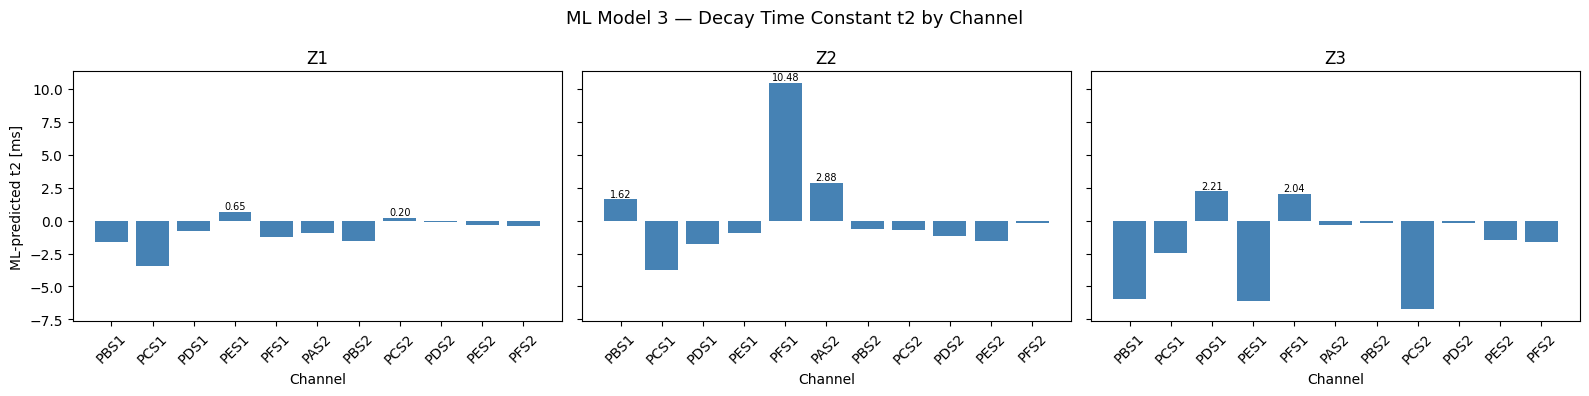


                      ML t2 (ms)    N events
----------------------------------------------
  Z1 PBS1             -1.59         259
  Z1 PCS1             -3.45          13
  Z1 PDS1             -0.78         134
  Z1 PES1              0.65          11
  Z1 PFS1             -1.21          13
  Z1 PAS2             -0.93          15
  Z1 PBS2             -1.54          15
  Z1 PCS2              0.20          11
  Z1 PDS2             -0.14          11
  Z1 PES2             -0.37          14
  Z1 PFS2             -0.40          13

  Z2 PBS1              1.62          15
  Z2 PCS1             -3.75          15
  Z2 PDS1             -1.76          15
  Z2 PES1             -0.93          15
  Z2 PFS1             10.48          14
  Z2 PAS2              2.88          15
  Z2 PBS2             -0.64          15
  Z2 PCS2             -0.74          15
  Z2 PDS2             -1.16          14
  Z2 PES2             -1.56          16
  Z2 PFS2             -0.17          14

  Z3 PBS1             -5.

In [44]:

# ── Bar chart: ML-predicted t2 per channel, grouped by detector ───────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, Z in zip(axes, Z_list):
    t2_vals, colors = [], []
    for ch in chanNames:
        val = t2_median.get((Z, ch), None)
        if val is not None:
            t2_vals.append(val * 1000)
            colors.append('steelblue')
        else:
            t2_vals.append(0)
            colors.append('lightgray')

    bars = ax.bar(chanNames, t2_vals, color=colors)
    ax.set_title(Z, fontsize=12)
    ax.set_xlabel('Channel')
    ax.tick_params(axis='x', rotation=45)
    for bar, v in zip(bars, t2_vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7)

axes[0].set_ylabel('ML-predicted t2 [ms]')
fig.suptitle('ML Model 3 — Decay Time Constant t2 by Channel', fontsize=13)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'':18s}  {'ML t2 (ms)':>12s}  {'N events':>10s}")
print('-' * 46)
for Z in Z_list:
    for ch in chanNames:
        key = (Z, ch)
        t2v = t2_median.get(key, None)
        n   = len(t2_by_ch.get(key, []))
        t2_str = f'{t2v*1000:.2f}' if t2v is not None else 'N/A'
        print(f'  {Z} {ch:<8s}  {t2_str:>12s}  {n:>10d}')
    print()


---
## Summary

| Model | Task | Key feature / input | Algorithm |
|-------|------|---------------------|-----------|
| 1 | Event quality (3-class) | 9 statistical features | Random Forest |
| 2 | Glitch detector (binary) | 9 statistical features | RF + MLP |
| 3 | Decay time t2 regression | aligned waveform window | 1D-CNN / MLP |

**Observation from Model 2**: the `pre_min` feature (pre-pulse dip) is the dominant discriminant between good and glitch events — consistent with the manual threshold used in `LED data.ipynb`.

**Limitation**: the labelled dataset is small (~30 glitch events total across all channels). More data from additional series / runs would improve generalisation.